In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [6]:
housing.target[:5]

array([4.526, 3.585, 3.521, 3.413, 3.422])

In [7]:
y = housing.target
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [8]:
df.shape

(20640, 8)

In [9]:
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

In [10]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [12]:
y.min(), y.max(), y.mean(), np.median(y)

(np.float64(0.14999),
 np.float64(5.00001),
 np.float64(2.0685581690891475),
 np.float64(1.797))

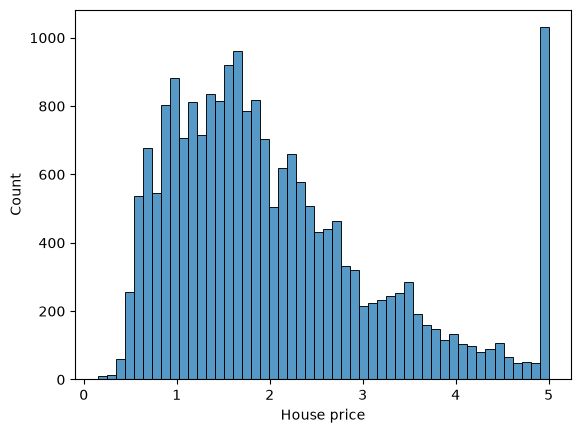

In [13]:
sns.histplot(y, bins=50)
plt.xlabel('House price')
plt.show()

In [14]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)

np.random.seed(2)
np.random.shuffle(idx)

In [15]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

y_train = y[idx[:n_train]]
y_val = y[idx[n_train:n_train+n_val]]
y_test = y[idx[n_train+n_val:]]

In [16]:
len(df_train), len(df_val), len(df_test)

(12384, 4128, 4128)

#### Linear Regression

In [17]:
X_train = df_train[['MedInc']].values

In [18]:
print(X_train.shape)
print(y_train.shape)

(12384, 1)
(12384,)


In [19]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    w0 = w_full[0]
    w = w_full[1:]

    return w0, w

#### Train

In [20]:
w0, w = train_linear_regression(X_train, y_train)

In [21]:
print("w0 =", w0)
print("w =", w)

w0 = 0.47396409406801937
w = [0.41190616]


#### Make predictions

In [22]:
y_pred = w0 + X_train.dot(w)

#### Train RMSE

In [23]:
def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

In [24]:
print(rmse(y_train, y_pred))

0.8437382870840484


#### Validation the model RMSE

In [25]:
X_val = df_val[['MedInc']].values

y_val_pred = w0 + X_val.dot(w)

rmse(y_val, y_val_pred)

np.float64(0.8249137557407006)

#### BaseLine model

In [26]:
X_train = df_train[['MedInc', 'HouseAge']].values
X_val = df_val[['MedInc', 'HouseAge']].values

In [27]:
w0, w = train_linear_regression(X_train, y_train)

print('w0 =', w0)
print('w =', w)

w0 = -0.08145036538876464
w = [0.42586663 0.01750591]


#### Training prediction + RMSE

In [28]:
y_train_pred = w0 + X_train.dot(w)

print('Train RMSE:', rmse(y_train, y_train_pred))

Train RMSE: 0.8145889679344557


#### Validation prediction + RMSE

In [29]:
y_val_pred = w0 + X_val.dot(w)

print('Validation RMSE:', rmse(y_val, y_val_pred))

Validation RMSE: 0.7942587559731222


In [30]:
features = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup',
    'Latitude',
    'Longitude'
]

X_train = df_train[features].values
X_val = df_val[features].values
X_test = df_test[features].values

In [31]:
w0 , w = train_linear_regression(X_train, y_train)

print('w0=', w0)
print('w=', w)

w0= -37.961701085117035
w= [ 4.48333891e-01  9.91303661e-03 -1.39510230e-01  9.18760645e-01
 -2.29499952e-06 -3.54064441e-03 -4.27426032e-01 -4.43306989e-01]


#### Training RMSE

In [32]:
y_train_pred = w0 + X_train.dot(w)

print('Train RMSE:', rmse(y_train, y_train_pred))

Train RMSE: 0.7210775486933778


#### Validation RMSE

In [33]:
y_val_pred = w0 + X_val.dot(w)

print('Validation RMSE:', rmse(y_val, y_val_pred))

Validation RMSE: 0.7072406680268072


#### Regularization

In [34]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)

    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [35]:
for r in [0, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1]:

    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_val_pred = w0 + X_val.dot(w)

    print(r, rmse(y_val, y_val_pred))

0 0.7072406680268072
1e-06 0.7072406617676407
1e-05 0.707240605444915
0.0001 0.7072400432672714
0.001 0.7072345259625292
0.01 0.7071895322249538
0.1 0.7075348686929456
1 0.7239553846017919


In [36]:
r = 0.01

w0, w = train_linear_regression_reg(X_train, y_train, r=r)

y_val_pred = w0 + X_val.dot(w)

print('r=', r)
print('w0=', w0)
print('Validation RMSE=', rmse(y_val, y_val_pred))

r= 0.01
w0= -37.451945152318
Validation RMSE= 0.7071895322249538


#### Train + validation

In [37]:
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

print(X_full.shape)
print(y_full.shape)

(16512, 8)
(16512,)


#### Train final model with selected r

In [38]:
r = 0.01

w0, w = train_linear_regression_reg(X_full, y_full, r=r)

print('w0=', w0)
print('w=', w)

w0= -37.20689148260357
w= [ 4.53034010e-01  9.90572335e-03 -1.38536739e-01  9.08173048e-01
 -2.21969422e-06 -3.51615741e-03 -4.21387521e-01 -4.35114331e-01]


#### Test

In [39]:
X_test = df_test[features].values

In [40]:
y_test_pred = w0 + X_test.dot(w)

In [41]:
print('Test RMSE:', rmse(y_test, y_test_pred))

Test RMSE: 0.7632506403710111


#### save the results

In [42]:
comparsion = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_test_pred[:10]
})

In [43]:
comparsion

,Actual,Predicted
0,0.55800,0.870243
1,1.40800,2.565232
2,0.94400,1.170320
3,5.00001,3.433297
4,1.90600,2.563358
5,0.81300,1.170672
6,2.35200,2.194289
7,2.33800,1.976470
8,2.22800,2.320504
9,3.93200,3.605888


#### average prediction error

In [44]:
errors = y_test - y_test_pred

print('Mean Error:', errors.mean())

Mean Error: -0.016684134920030885
